Introduction to encoding models

This tutorial introduces linear encoding models in language neuroscience. You will learn how to build a ridge regression model which uses stimulus features (LLM word embeddings) to predict speech-evoked neural activity.

This tutorial draws upon the ["Podcast" ECoG dataset](https://www.nature.com/articles/s41597-025-05462-2), and open source set of intracranial neural recording in epilepy patients who listened to one episode of the This American Life Podcast. Handily, this dataset already comes with several pre-computed feature spaces. For this tutorial, we will use LLM contextual word embeddings from GPT2 to predict neural activity. Encoding models use linear regression to map features onto brain activity. Here, we will use the [Himalaya](https://gallantlab.org/himalaya/index.html) package to train encoding models using ridge regression.

**Acknowledgments:** This tutorial builds directly upon the encoding notebook in the [Podcast ECoG Tutorials](https://github.com/hassonlab/podcast-ecog-tutorials) made by members of the Hasson Lab at Princeton University.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bootstrapbill/encoding_model_tutorial/blob/main/notebooks/encoding_tutorial.ipynb)

**Note:** Before running the tutorial click 'Runtime' -> 'Change runtime type' -> 'T4 GPU' to switch from CPU to GPU for faster model fitting.


In [1]:
# only run this cell in colab

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
!pip install mne mne_bids himalaya scikit-learn pandas matplotlib nilearn

Looking in indexes: https://download.pytorch.org/whl/cu124


In [2]:
import mne
import h5py
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn.plotting import plot_markers
from mne_bids import BIDSPath

from himalaya.backend import set_backend, get_backend
from himalaya.ridge import RidgeCV
from himalaya.scoring import correlation_score

from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

We will set the [Himalaya backend](https://gallantlab.org/himalaya/_generated/himalaya.backend.set_backend.html#himalaya.backend.set_backend) to `torch_cuda` so we can utilize a GPU for training, if available.

In [3]:
if torch.cuda.is_available():
    set_backend("torch_cuda")
    print("Using cuda!")

Using cuda!


## Loading the language features

We will now load contextual word embeddings, which the Hasson lab previously extracted from GPT-2. The loaded features should be a numpy array with a shape of (number of tokens * feature dimensions).

In [4]:
# download the features
bids_root = ''

embedding_path = f"{bids_root}stimuli/gpt2-xl/features.hdf5"
if not len(bids_root):
    !wget -nc https://s3.amazonaws.com/openneuro.org/ds005574/$embedding_path
    embedding_path = "features.hdf5"

print(f"Using embedding file path: {embedding_path}")

--2026-04-10 21:17:38--  https://s3.amazonaws.com/openneuro.org/ds005574/stimuli/gpt2-xl/features.hdf5
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.253.225, 16.15.217.105, 52.216.209.152, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.253.225|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1721998080 (1.6G) [application/x-hdf5]
Saving to: ‘features.hdf5’

features.hdf5       100%[===================>]   1.60G  13.1MB/s    in 2m 11s  

2026-04-10 21:19:50 (12.6 MB/s) - ‘features.hdf5’ saved [1721998080/1721998080]

Using embedding file path: features.hdf5


In [5]:
modelname, layer = 'gpt2-xl', 24
with h5py.File(embedding_path, "r") as f:
    contextual_embeddings = f[f"layer-{layer}"][...]
print(f"LLM embedding matrix has shape: {contextual_embeddings.shape}")

LLM embedding matrix has shape: (5491, 1600)


We will also load the stimuli transcripts which contain information about the word, token, start (onset), and end (offset). The contextual word embedding transcript should also include other prediction information extracted from GPT-2, like rank, probability, and entropy. For instance, we can calculate how accurate the model is in predicting the next token in the transcript based on the `rank` column, which are integers that represents the rank of the actual token in all the possible tokens of GPT-2.

Note: Check that the transcript contains the same number of tokens as the features we loaded before.

In [11]:
# download the transcript
transcript_path = f"{bids_root}stimuli/gpt2-xl/transcript.tsv"
if not len(bids_root):
    !wget -nc https://s3.amazonaws.com/openneuro.org/ds005574/$transcript_path
    transcript_path = "transcript.tsv"

# load transcript
df_contextual = pd.read_csv(transcript_path, sep="\t", index_col=0)

if "rank" in df_contextual.columns:
    model_acc = (df_contextual["rank"] == 0).mean()
    print(f"Model accuracy: {model_acc*100:.3f}%")

df_contextual.head()


File ‘transcript.tsv’ already there; not retrieving.

Model accuracy: 30.942%


,word_idx,word,start,end,hftoken,token_id,rank,true_prob,top_pred,entropy
0,0,Act,3.710,3.790,ĠAct,2191,1644,0.000012,0,2.402717
1,1,"one,",3.990,4.190,Ġone,530,92,0.000342,352,3.732053
2,1,"one,",3.990,4.190,",",11,3,0.059520,25,4.259335
3,2,monkey,4.651,4.931,Ġmonkey,21657,4022,0.000018,3715,6.621269
4,3,in,4.951,5.011,Ġin,287,15,0.004237,0,4.444838


When we extracted features, some words are split into separate tokens. Since we only have information of start and end for words, we will align the features from tokens to words for encoding models. Here, we simply average the token features across the same word. Now the features should be a numpy array with a shape of (number of words * feature dimensions).

In [52]:
aligned_embeddings = []
for _, group in df_contextual.groupby("word_idx"): # group by word index
    indices = group.index.to_numpy()
    average_emb = contextual_embeddings[indices].mean(0) # average features
    aligned_embeddings.append(average_emb)
aligned_embeddings = np.stack(aligned_embeddings)
print(f"LLM embeddings matrix has shape: {aligned_embeddings.shape}")


LLM embeddings matrix has shape: (5136, 1600)


We will also construct a dataframe containing words with their start and end timestamps.

In [32]:
df_word = df_contextual.groupby("word_idx").agg(dict(word="first", start="first", end="last", true_prob="prod"))
df_word.head()

,word,start,end,true_prob
word_idx,,,,
0,Act,3.710,3.790,0.000012
1,"one,",3.990,4.190,0.000020
2,monkey,4.651,4.931,0.000018
3,in,4.951,5.011,0.004237
4,the,5.051,5.111,0.392205


Let's now visualise the embeddings for some different words to get a sense of how the model is representing them.

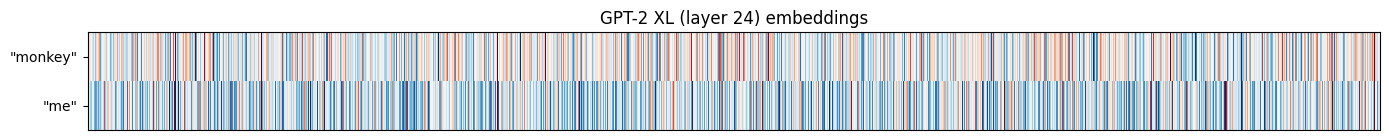

In [33]:

# Pick two words to compare (try changing these!)
word1, word2 = "monkey", "me"

# Build a word-level lookup: one embedding per word occurrence
words = df_contextual.groupby("word_idx").first()["word"].values

# Find the first occurrence of each word
idx1 = np.where(words == word1)[0][0]
idx2 = np.where(words == word2)[0][0]

emb1 = aligned_embeddings[idx1]
emb2 = aligned_embeddings[idx2]

# Stack into a 2×D matrix for imshow
matrix = np.stack([emb1, emb2])

# Symmetric color limits so 0 is white
vmax = 10 # max(abs(matrix.min()), abs(matrix.max()))

fig, ax = plt.subplots(figsize=(14, 1.5))
ax.imshow(matrix, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.set_yticks([0, 1])
ax.set_yticklabels([f'"{word1}"', f'"{word2}"'])
ax.set_xticks([])
ax.set_title(f"GPT-2 XL (layer {layer}) embeddings")
plt.tight_layout()
plt.show()



Note, these models use contextual embeddings, so the same word will be represented differently depending on the context in which is occurs. Lets explore that briefly...

Found 48 occurrences of "monkey"


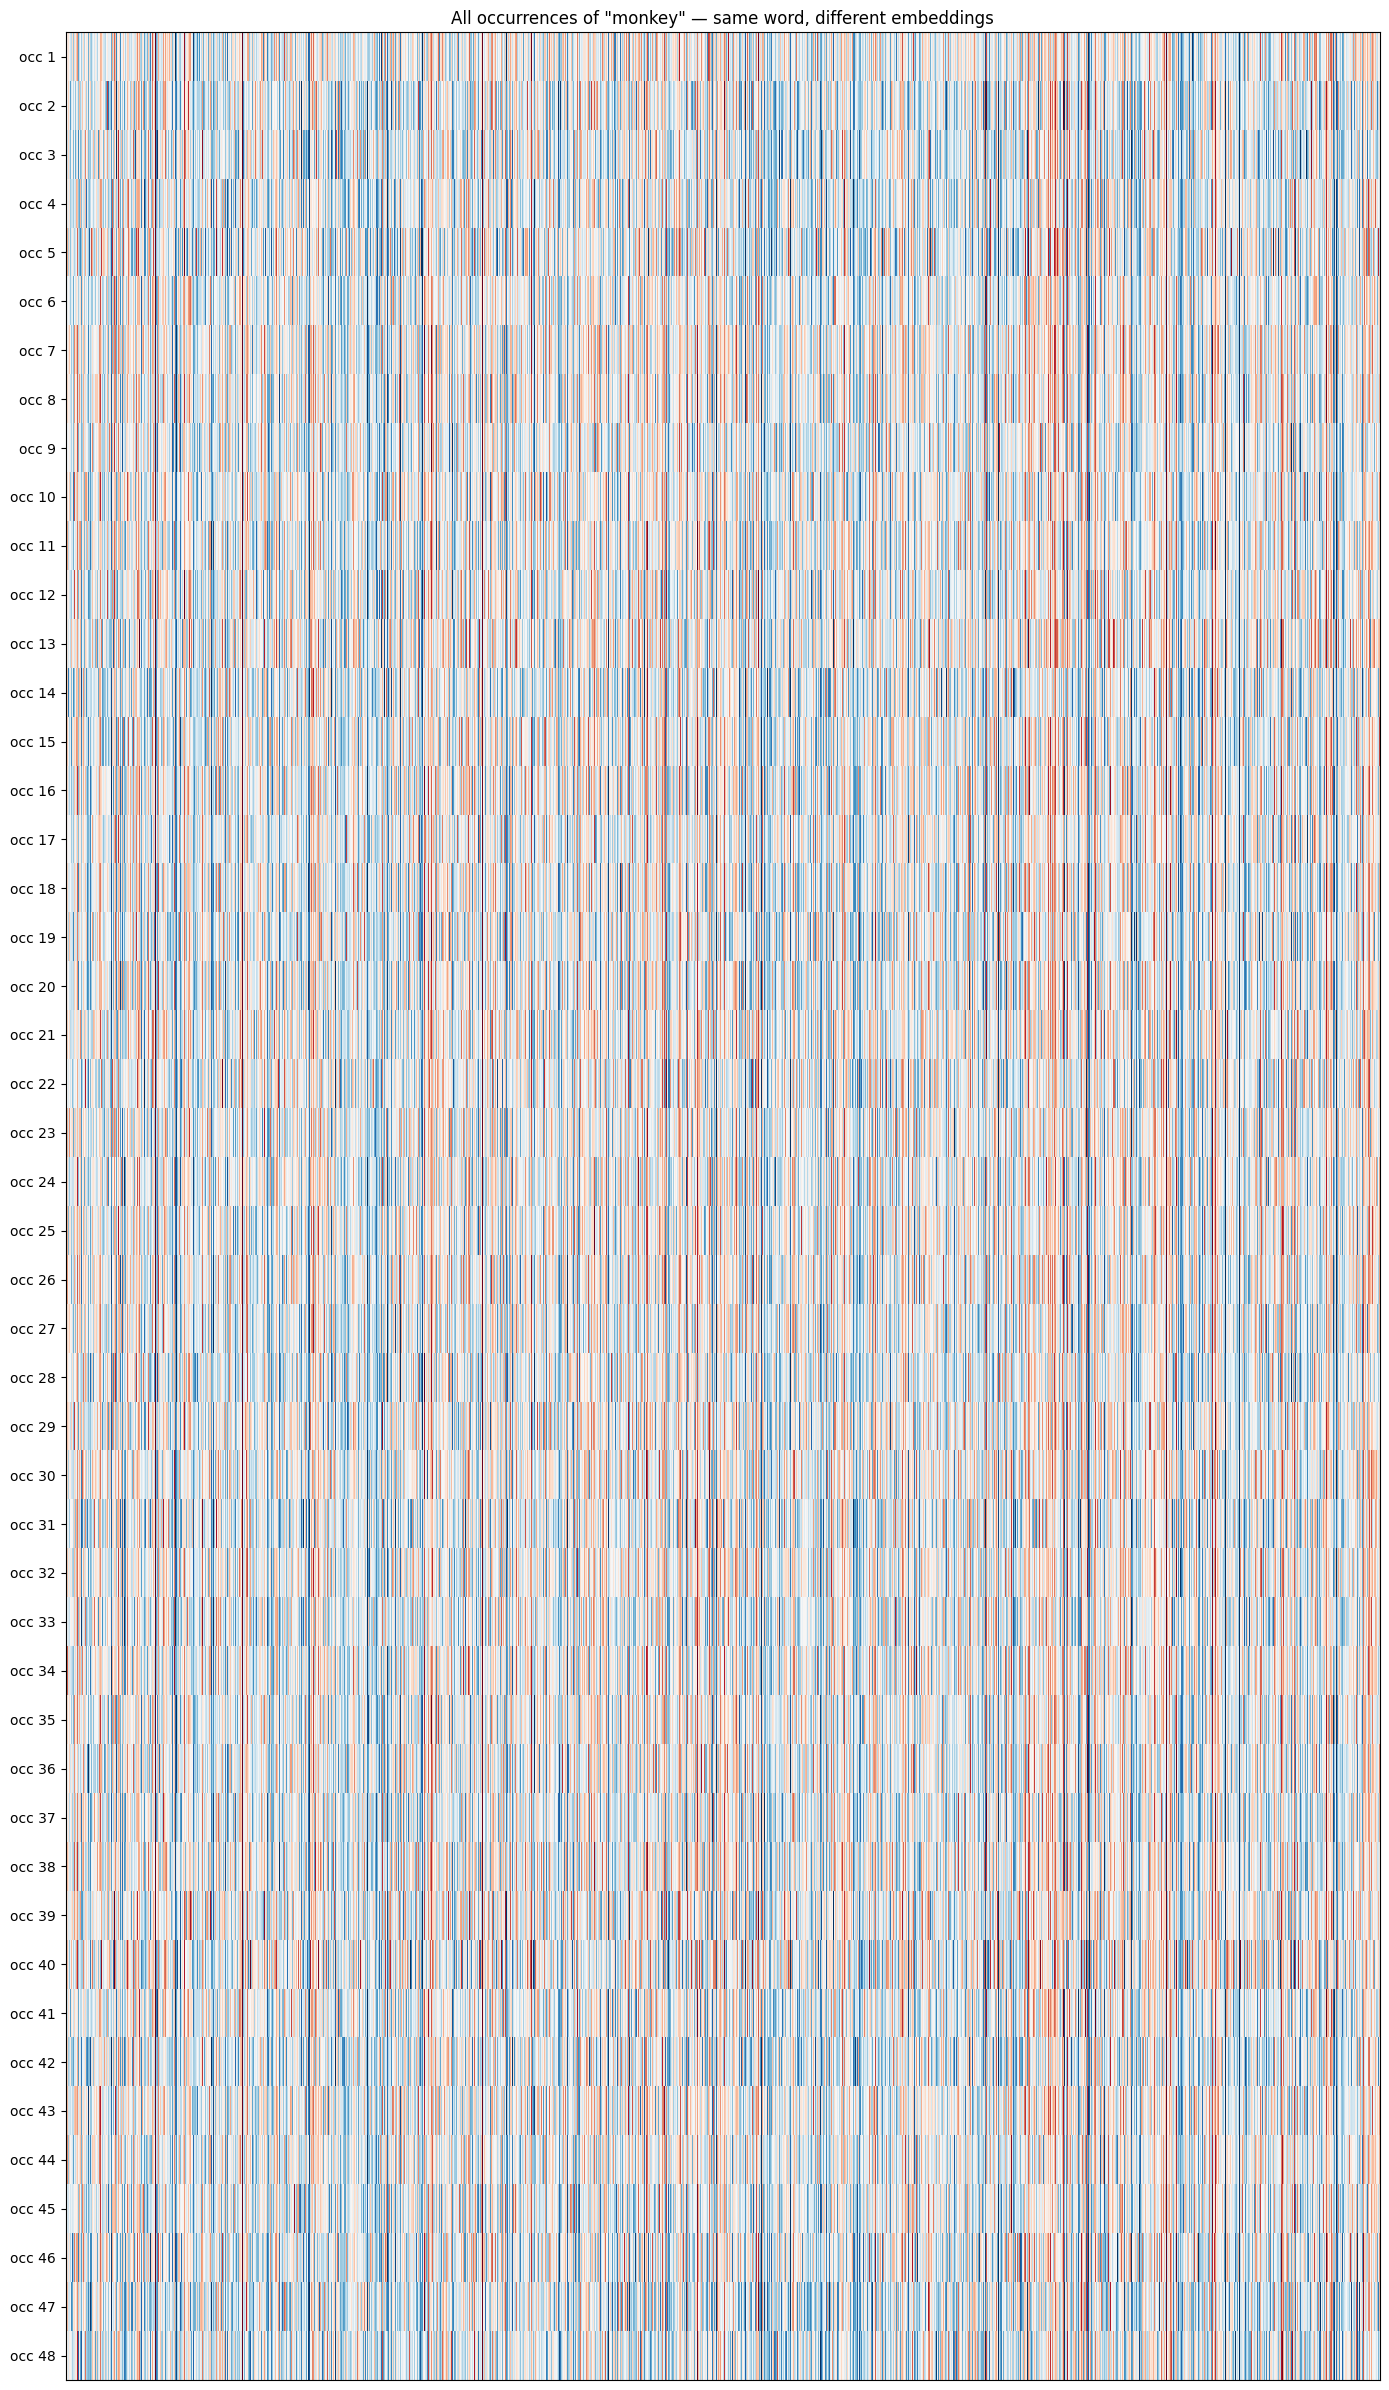

In [34]:

# Because GPT-2 is a contextual model, the same word gets a different
# embedding depending on the surrounding words. Let's see this in action.

target_word = "monkey"

# Find all occurrences of the target word
word_labels = df_contextual.groupby("word_idx").first()["word"].values
occurrences = np.where(word_labels == target_word)[0]

print(f'Found {len(occurrences)} occurrences of "{target_word}"')

# Stack embeddings into a matrix (n_occurrences × D)
embs = aligned_embeddings[occurrences]

# Symmetric color limits so 0 is white
vmax = 10 # np.max(np.abs(embs))

fig, ax = plt.subplots(figsize=(14, max(1.5, 0.5 * len(occurrences))))
ax.imshow(embs, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.set_yticks(range(len(occurrences)))
ax.set_yticklabels([f"occ {i+1}" for i in range(len(occurrences))])
ax.set_xticks([])
ax.set_title(f'All occurrences of "{target_word}" — same word, different embeddings')
plt.tight_layout()
plt.show()

## Loading the neural data

Next, we will load the preprocessed high-gamma ECoG data, using data from the third subject. We will load this in from [OpenNeuro.org](https://openneuro.org/), an online data repository for neuroimaging experiments.

In [21]:
file_path = BIDSPath(root=f"{bids_root}derivatives/ecogprep",
                    subject="03", task="podcast", datatype="ieeg", description="highgamma",
                    suffix="ieeg", extension=".fif")
print(f"File path within the dataset: {file_path}")

# You only need to run this if using Colab (i.e. if you did not set bids_root to a local directory)
if not len(bids_root):
    !wget -nc https://s3.amazonaws.com/openneuro.org/ds005574/$file_path
    file_path = file_path.basename

raw = mne.io.read_raw_fif(file_path, verbose=False)
picks = mne.pick_channels_regexp(raw.ch_names, "LG[AB]*")
raw = raw.pick(picks)
raw

File path within the dataset: derivatives/ecogprep/sub-03/ieeg/sub-03_task-podcast_desc-highgamma_ieeg.fif
--2026-04-10 21:39:41--  https://s3.amazonaws.com/openneuro.org/ds005574/derivatives/ecogprep/sub-03/ieeg/sub-03_task-podcast_desc-highgamma_ieeg.fif
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.244.122, 16.182.43.16, 16.15.199.131, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.244.122|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 866371015 (826M) [biosig/fiff]
Saving to: ‘sub-03_task-podcast_desc-highgamma_ieeg.fif’

sub-03_task-podcast 100%[===================>] 826.24M  16.4MB/s    in 50s     

2026-04-10 21:40:32 (16.5 MB/s) - ‘sub-03_task-podcast_desc-highgamma_ieeg.fif’ saved [866371015/866371015]



<Raw | sub-03_task-podcast_desc-highgamma_ieeg.fif, 127 x 921600 (1800.0 s), ~187 KiB, data not loaded>

We will map the onset of each word (in seconds) onto the brain signal data by multiplying by the sampling rate. Here the first column of `events` mark the start of each word on the neural data.

In [23]:
events = np.zeros((len(df_word), 3), dtype=int)
events[:, 0] = (df_word.start * raw.info['sfreq']).astype(int)
events.shape

(5136, 3)

Next, we take advantage of MNE's tools for creating epochs around stimulus events, which we have defined as the onset of each word. Here, we take a fixed-width window ranging from -2 seconds to +2 seconds relative to word onset. Since the sampling rate is 512 Hz (512 samples per second), we have 2049 lags total. The ECoG data is a numpy array with shape: number of words * number of ECoG electrodes * number of lags.

In [24]:
epochs = mne.Epochs(
    raw,
    events,
    tmin=-2.0,
    tmax=2.0,
    baseline=None,
    proj=False,
    event_id=None,
    preload=True,
    event_repeated="merge",
)
print(f"Epochs object has a shape of: {epochs._data.shape}")

Not setting metadata
5136 matching events found
No baseline correction applied
Loading data for 5136 events and 2049 original time points ...


/tmp/ipykernel_571/3482921024.py:1: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.Epochs(


6 bad epochs dropped
Epochs object has a shape of: (5130, 127, 2049)


Next, we'll downsample the temporal resolution to 32 Hz, which reduces the number of lags to 32 * 4 = 128. This just helps to speed up the model fitting below.

In [25]:
epochs = epochs.resample(sfreq=32, npad='auto', method='fft', window='hamming')
print(f"Epochs object has a shape of: {epochs._data.shape}")

Epochs object has a shape of: (5130, 127, 128)


Now let's quickly visualise the word-locked neural responses for a few electrodes, to get a sense of what the neural dynamics look like!

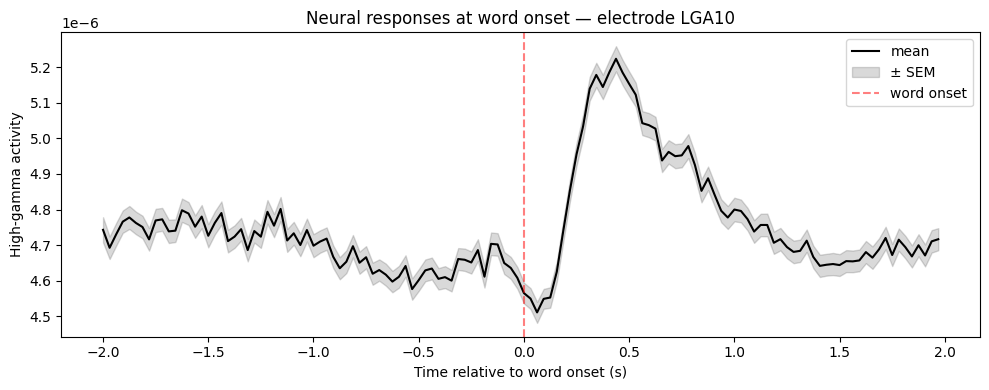

In [35]:

# Pick an electrode to inspect (try changing this!) using any name from: epochs.ch_names
electrode = "LGA10"
ch_idx = epochs.ch_names.index(electrode)

# Get the epoch data for this electrode: (n_words, n_timepoints)
erp_data = epochs.get_data(copy=True)[:, ch_idx, :]
times = epochs.times  # time axis in seconds, 0 = word onset

fig, ax = plt.subplots(figsize=(10, 4))

# Plot the mean ± SEM
mean_resp = erp_data.mean(axis=0)
sem_resp = erp_data.std(axis=0) / np.sqrt(erp_data.shape[0])
ax.plot(times, mean_resp, color="black", linewidth=1.5, label="mean")
ax.fill_between(times, mean_resp - sem_resp, mean_resp + sem_resp,
                color="black", alpha=0.15, label="± SEM")

ax.axvline(0, color="red", linestyle="--", alpha=0.5, label="word onset")
ax.set_xlabel("Time relative to word onset (s)")
ax.set_ylabel("High-gamma activity")
ax.set_title(f"Neural responses at word onset — electrode {electrode}")
ax.legend()
plt.tight_layout()
plt.show()

## Setting up feature and brain data

Now we have both the features and the ECoG data ready. We plan to fit encoding models at each electrode and for each lag, so we'll reshape our target matrix `Y` to horizontally stack both electrodes and lags along the second dimension.

In [40]:
epochs_data = epochs.get_data(copy=True)
epochs_data = epochs_data.reshape(len(epochs), -1)
print(f"ECoG data matrix shape: {epochs_data.shape}")

ECoG data matrix shape: (5130, 16256)


We will also align our features with the ECoG data.

In [41]:
selected_df = df_word.iloc[epochs.selection]
averaged_embeddings = aligned_embeddings[epochs.selection]
print(averaged_embeddings.shape)

(5130, 1600)


We will change the float precision to float32 for all data to take advantage of the GPU memory and computational speed.

In [42]:
X = averaged_embeddings
Y = epochs_data

if "torch" in get_backend().__name__:
    X = X.astype(np.float32)
    Y = Y.astype(np.float32)

X.shape, Y.shape

((5130, 1600), (5130, 16256))

## Building encoding models

Now, we will use ridge regression to estimate the encoding model. We create a model pipeline using `sklearn`, which includes a [StandardScaler](https://scikit-learn.org/dev/modules/generated/sklearn.preprocessing.StandardScaler.html) that standardizes the features (X), and a [RidgeCV](https://gallantlab.org/himalaya/_generated/himalaya.ridge.RidgeCV.html) model, which performs ridge regression with cross-validation over our specificed alpha values.

In [43]:
alphas = np.logspace(1, 10, 10) # specify alpha values
inner_cv = KFold(n_splits=5, shuffle=False) # inner 5-fold cross-validation setup
model = make_pipeline(
    StandardScaler(), RidgeCV(alphas, fit_intercept=True, cv=inner_cv) # pipeline
)
model

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('ridgecv',
                 RidgeCV(alphas=array([1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05, 1.e+06, 1.e+07, 1.e+08,
       1.e+09, 1.e+10]),
                         cv=KFold(n_splits=5, random_state=None, shuffle=False),
                         fit_intercept=True))])

## Training encoding models

While `RidgeCV` contains an inner cross-validation setup to find the best alpha, we will also set up an outer cross-validation loop to evaluate our encoding model. Here, we will use k = 2, meaning we will train on half of the data and evaluate on the other half. Within each fold, we will split the train and test dataset. Then we will standardize `Y` the same way we standardize `X` in the pipeline. We will then fit our model on the training dataset and use it to predict for the testing dataset. For evaluation, we will calculate correlation scores between `Y_preds`, the ECoG signal predicted by our model, and `Y_test`, the actual ECoG signal. The encoding model is trained and evaluated for each electrode and each lag.

In [44]:
epochs_shape = epochs._data.shape[1:] # number of electrodes * number of lags

def train_encoding(X, Y):

    corrs = [] # empty array to store correlation results
    kfold = KFold(2, shuffle=False) # outer 2-fold cross-validation setup
    for train_index, test_index in kfold.split(X): # loop through folds

        # Split train and test datasets
        X1_train, X1_test = X[train_index], X[test_index]
        Y_train, Y_test = Y[train_index], Y[test_index]

        # Standardize Y
        scaler = StandardScaler()
        Y_train = scaler.fit_transform(Y_train)
        Y_test = scaler.transform(Y_test)

        model.fit(X1_train, Y_train) # Fit pipeline with transforms and ridge estimator
        Y_preds = model.predict(X1_test) # Use trained model to predict on test set
        corr = correlation_score(Y_test, Y_preds).reshape(epochs_shape) # Compute correlation score

        if "torch" in get_backend().__name__: # if using gpu, transform tensor back to numpy
            corr = corr.numpy(force=True)

        corrs.append(corr) # append fold correlation results to final results
    return np.stack(corrs)

# set_backend("torch") # resort to torch or numpy if cuda out of memory
corrs_embedding = train_encoding(X, Y)
print(f"Encoding performance correlating matrix shape: {corrs_embedding.shape}")

Encoding performance correlating matrix shape: (2, 127, 128)


## Plotting encoding performance

We trained and evaluated many encoding models. We have 127 electrodes and 128 lags for each, and on top of that we split the podcast into two 15-minute chunks to train on one half and test on the other. Thus, we have correlations for each of these in one array. Below, we will summarize these results in two ways: spatially and temporally.

First we summarize spatially by averaging over all electrodes and looking at the average temporal pattern of correlations. We notice that encoding performance increases after word onset and is lower near ± 2 seconds.

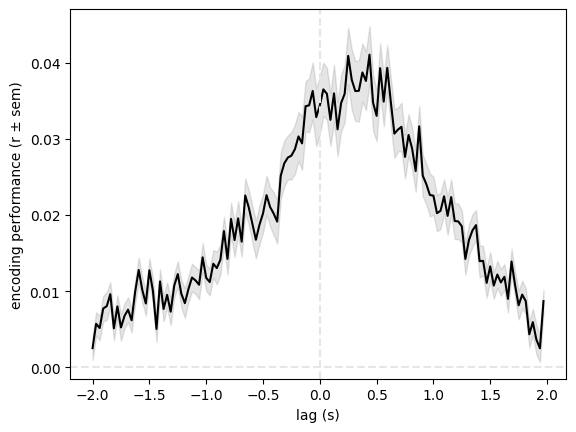

In [45]:
lags = np.arange(-2 * 512, 2 * 512, 16) / 512 # specify the lags
mean = corrs_embedding.mean((0,1))
err = corrs_embedding.std((0,1)) / np.sqrt(np.prod(corrs_embedding.shape[:2]))

fig, ax = plt.subplots()
ax.plot(lags, mean, color='black')
ax.fill_between(lags, mean - err, mean + err, alpha=0.1, color='black')
ax.set_xlabel("lag (s)")
ax.set_ylabel("encoding performance (r ± sem)")
ax.axvline(0, c=(.9, .9, .9), ls="--")
ax.axhline(0, c=(.9, .9, .9), ls="--")
fig.show()

Next we summarize temporally by selecting the maximum correlation across lags per electrode. Now that we have one correlation per electrode, we plot the results on the brain.

Coordinate matrix shape:  (127, 3)


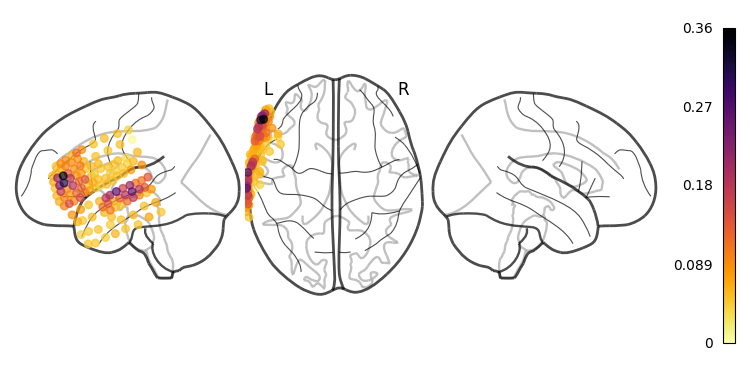

In [46]:
values = corrs_embedding.mean(0).max(-1)

ch2loc = {ch['ch_name']: ch['loc'][:3] for ch in raw.info['chs']}
coords = np.vstack([ch2loc[ch] for ch in raw.info['ch_names']])
coords *= 1000  # nilearn likes to plot in meters, not mm
print("Coordinate matrix shape: ", coords.shape)

order = values.argsort()
plot_markers(values[order], coords[order],
             node_size=30, display_mode='lzr',
             node_vmin=0, node_cmap='inferno_r', colorbar=True)
plt.show()

Let's also look at the model predictions overlaid on neural activity, for a given electrode.

Electrode: LGA10, best lag: 0.34 s


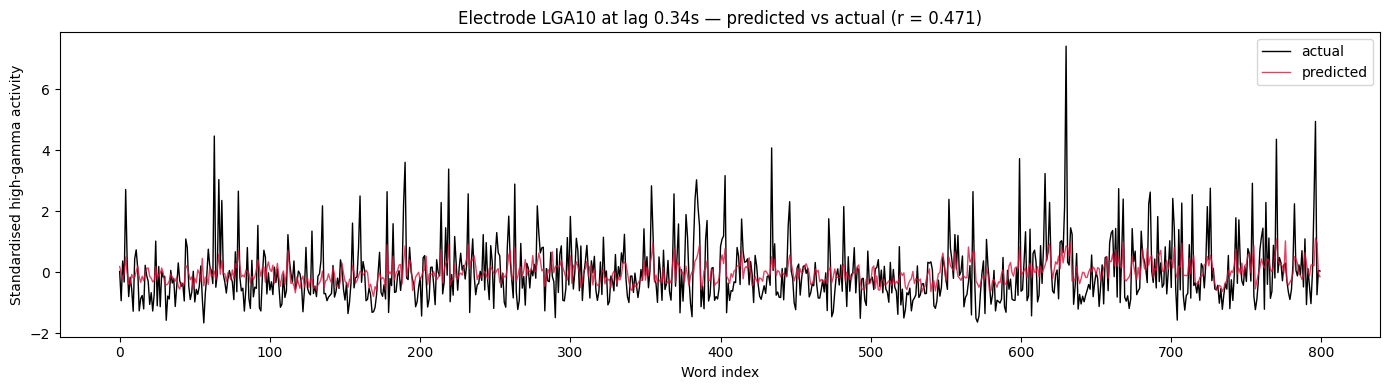

In [47]:

# NOTE: here we are predicting on data the model has (partially) seen during training.
# This is for visualisation purposes only — not a proper held-out evaluation.

# Predict on the full dataset using the already-fitted model
Y_sc = StandardScaler().fit_transform(Y)
Y_preds_sc = model.predict(X)

# Reshape to (n_words, n_electrodes, n_lags)
Y_actual = Y_sc.reshape(-1, *epochs_shape)
Y_predicted = Y_preds_sc.reshape(-1, *epochs_shape)

# Pick an electrode and its best lag
electrode = "LGA10"
ch_idx = epochs.ch_names.index(electrode)
best_lag_idx = corrs_embedding.mean(0)[ch_idx].argmax()
lags = np.arange(-2 * 512, 2 * 512, 16) / 512
print(f"Electrode: {electrode}, best lag: {lags[best_lag_idx]:.2f} s")

# Extract word-by-word time series at this electrode and lag
actual = Y_actual[:, ch_idx, best_lag_idx]
predicted = Y_predicted[:, ch_idx, best_lag_idx]
r = np.corrcoef(actual, predicted)[0, 1]

# Plot a segment
n_show = 800
fig, ax = plt.subplots(figsize=(14, 4))
word_idx = np.arange(n_show)
ax.plot(word_idx, actual[:n_show], color="black", linewidth=1, label="actual")
ax.plot(word_idx, predicted[:n_show], color="crimson", linewidth=1, alpha=0.8, label="predicted")
ax.set_xlabel("Word index")
ax.set_ylabel("Standardised high-gamma activity")
ax.set_title(f"Electrode {electrode} at lag {lags[best_lag_idx]:.2f}s — "
             f"predicted vs actual (r = {r:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

So we've successfully fit a model to predict brain responses to speech using word embeddings from LLMs -- how cool! But this is where the really tricky work begins... we now need to think about why the embeddings allow us to predict neural responses, and what exactly this tells us about language processing in the brain. This is a very active (and complex) area of research and debate, so we will not answer that question today. But we would urge you to go away and think about what you can (and cannot) conclude from results like these.

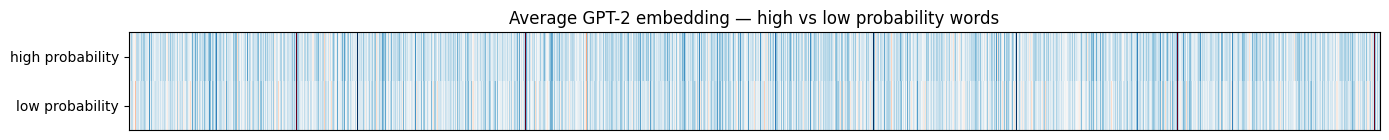

In [51]:
# Split embeddings by word probability
high_prob_emb = averaged_embeddings[high_prob_mask].mean(axis=0)
low_prob_emb = averaged_embeddings[low_prob_mask].mean(axis=0)

# Stack into a 2×D matrix for imshow
matrix = np.stack([high_prob_emb, low_prob_emb])
vmax = 5 # np.max(np.abs(matrix))

fig, ax = plt.subplots(figsize=(14, 1.5))
ax.imshow(matrix, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.set_yticks([0, 1])
ax.set_yticklabels(["high probability", "low probability"])
ax.set_xticks([])
ax.set_title("Average GPT-2 embedding — high vs low probability words")
plt.tight_layout()
plt.show()

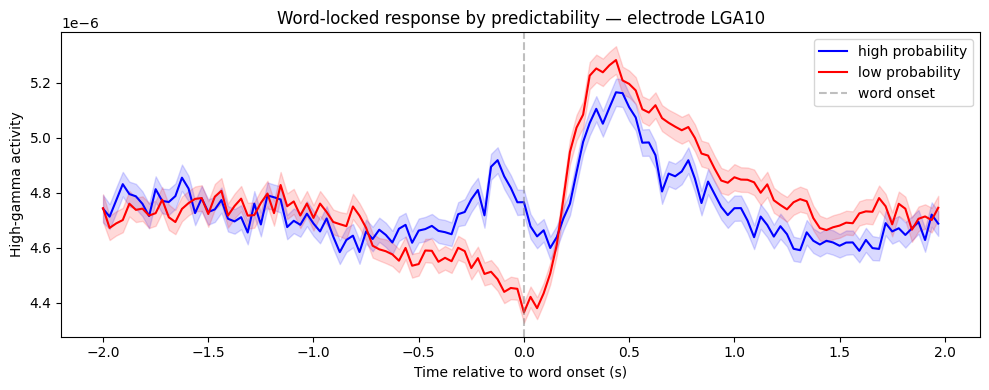

In [48]:

# Pick an electrode to inspect (try changing this!) using any name from: epochs.ch_names
electrode = "LGA10"
ch_idx = epochs.ch_names.index(electrode)

# Get the epoch data for this electrode: (n_words, n_timepoints)
erp_data = epochs.get_data(copy=True)[:, ch_idx, :]
times = epochs.times  # time axis in seconds, 0 = word onset

# Split by word probability (median split)
probs = selected_df["true_prob"].values
median_prob = np.median(probs)
high_prob_mask = probs >= median_prob
low_prob_mask = probs < median_prob

fig, ax = plt.subplots(figsize=(10, 4))

for mask, label, color in [(high_prob_mask, "high probability", "blue"),
                            (low_prob_mask, "low probability", "red")]:
    mean_resp = erp_data[mask].mean(axis=0)
    sem_resp = erp_data[mask].std(axis=0) / np.sqrt(mask.sum())
    ax.plot(times, mean_resp, color=color, linewidth=1.5, label=label)
    ax.fill_between(times, mean_resp - sem_resp, mean_resp + sem_resp,
                    color=color, alpha=0.15)

ax.axvline(0, color="grey", linestyle="--", alpha=0.5, label="word onset")
ax.set_xlabel("Time relative to word onset (s)")
ax.set_ylabel("High-gamma activity")
ax.set_title(f"Word-locked response by predictability — electrode {electrode}")
ax.legend()
plt.tight_layout()
plt.show()
